In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

In [ ]:
df.shape

(50000, 2)

In [ ]:
df.sample(10)

,review,sentiment
46451,BSG is one of my all time favourite TV series....,positive
3059,"Pretty twisted Horror film, that has a few goo...",negative
44354,Bedrooms and Hallways was one of the funniest ...,positive
34296,The episodic version of Robert Heinlein's Star...,negative
44636,I just watched Holly along with another movie ...,positive
10595,(My Synopsis) Rae (Christina Ricci) was a high...,positive
49737,I hated this show when I was a kid. That was b...,negative
2505,Aaah...The Thing.<br /><br />To see a horror f...,positive
32279,This Is one of my favourite westerns. What a c...,positive
18302,I've watched the first 15 minutes and I can te...,negative


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
from bs4 import BeautifulSoup
import re

def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^a-z0-9'/\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["review"] = df["review"].apply(clean_text)

In [ ]:

# This cell creates a Python file containing the clean_text function.
# This file is then imported by subsequent cells for preprocessing new text.
with open('text_preprocessing_utils.py', 'w') as f:
    f.write('''from bs4 import BeautifulSoup
import re

def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^a-z0-9'/\s]", ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text
''')
print("text_preprocessing_utils.py created successfully.")


text_preprocessing_utils.py created successfully.


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1102/1025112558.py:10: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub(r"[^a-z0-9'/\s]", ' ', text)


In [ ]:
print(df["review"].iloc[3])

basically there's a family where a little boy jake thinks there's a zombie in his closet his parents are fighting all the time this movie is slower than a soap opera and suddenly jake decides to become rambo and kill the zombie ok first of all when you're going to make a film you must decide if its a thriller or a drama as a drama the movie is watchable parents are divorcing arguing like in real life and then we have jake with his closet which totally ruins all the film i expected to see a boogeyman similar movie and instead i watched a drama with some meaningless thriller spots 3 out of 10 just for the well playing parents descent dialogs as for the shots with jake just ignore them


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["sentiment"] = encoder.fit_transform(df["sentiment"])

In [ ]:
X = df["review"]
y = df["sentiment"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

In [ ]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'in': 7,
 'it': 8,
 'i': 9,
 'this': 10,
 'that': 11,
 'was': 12,
 'as': 13,
 'for': 14,
 'with': 15,
 'movie': 16,
 'but': 17,
 'film': 18,
 'on': 19,
 'not': 20,
 'you': 21,
 'are': 22,
 'his': 23,
 'have': 24,
 'be': 25,
 'one': 26,
 'he': 27,
 'all': 28,
 'at': 29,
 'by': 30,
 'an': 31,
 'they': 32,
 'so': 33,
 'who': 34,
 'from': 35,
 'like': 36,
 'or': 37,
 'just': 38,
 'her': 39,
 'out': 40,
 'if': 41,
 'about': 42,
 "it's": 43,
 'has': 44,
 'there': 45,
 'some': 46,
 'what': 47,
 'good': 48,
 'when': 49,
 'more': 50,
 'very': 51,
 'up': 52,
 'no': 53,
 'time': 54,
 'even': 55,
 'my': 56,
 'would': 57,
 'she': 58,
 'which': 59,
 'really': 60,
 'only': 61,
 'see': 62,
 'story': 63,
 'their': 64,
 'had': 65,
 'can': 66,
 'me': 67,
 'were': 68,
 'well': 69,
 'we': 70,
 'much': 71,
 'than': 72,
 'bad': 73,
 'been': 74,
 'get': 75,
 'do': 76,
 'will': 77,
 'also': 78,
 'other': 79,
 'great': 80,
 'into': 81,
 'people': 82,

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
review_lengths = X_train.apply(lambda x: len(x.split()))

print(review_lengths.describe())

count    40000.000000
mean       230.957225
std        170.524596
min          6.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2466.000000
Name: review, dtype: float64


In [ ]:
print(review_lengths.quantile(0.90))
print(review_lengths.quantile(0.95))
print(review_lengths.quantile(0.99))

451.0
588.0
900.010000000002


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 600

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [ ]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 600)
(10000, 600)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:

vocab_size = 10000
embedding_dim = 128

model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.7471 - loss: 0.5262 - val_accuracy: 0.8346 - val_loss: 0.3830
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 77s 77ms/step - accuracy: 0.8698 - loss: 0.3247 - val_accuracy: 0.8859 - val_loss: 0.2814
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.9116 - loss: 0.2360 - val_accuracy: 0.9054 - val_loss: 0.2415
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.9388 - loss: 0.1758 - val_accuracy: 0.9056 - val_loss: 0.2369
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.9573 - loss: 0.1305 - val_accuracy: 0.8834 - val_loss: 0.3159
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.9710 - loss: 0.0944 - val_accuracy: 0.8979 - val_loss: 0.3285
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.9808 - loss: 0.0694 - val_accuracy: 0.8903 - val_loss: 0.4085


In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8990 - loss: 0.2545
Test Loss: 0.2545
Test Accuracy: 0.8990


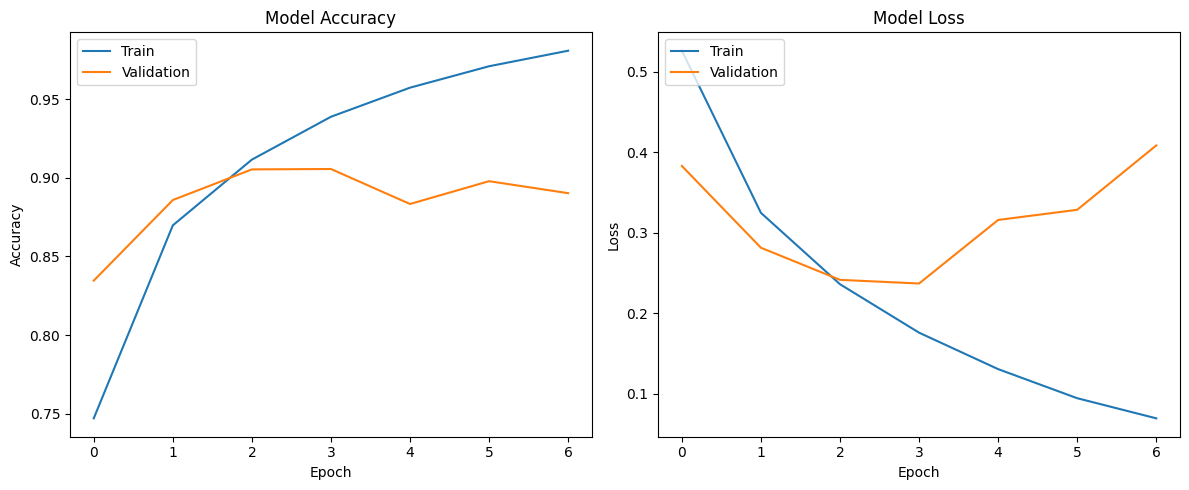

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
model.save('sentiment_model.keras')

In [ ]:
import pickle

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved as 'tokenizer.pkl'")

# Save the LabelEncoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("LabelEncoder saved as 'label_encoder.pkl'")

Tokenizer saved as 'tokenizer.pkl'
LabelEncoder saved as 'label_encoder.pkl'
